### **Imports & Setup**

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import re       # Regular Expressions for advanced text pattern matching
import emoji    # Handling and removing emojis from text
import nltk     # Natural Language Toolkit for linguistic tasks
from nltk.corpus import stopwords       # Common words to be filtered out (e.g., "من", "في")
from nltk.stem.isri import ISRIStemmer  # Arabic-specific stemmer to find word roots
from sklearn.feature_extraction.text import TfidfVectorizer # Converting text to numerical TF-IDF features
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score # Cross-validation with preserved class proportions , Evaluating model performance across multiple folds
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    classification_report, accuracy_score,
    confusion_matrix, ConfusionMatrixDisplay    # Visual representation of the confusion matrix
)
import pickle   # Serializing and saving the trained model to a file
import warnings
warnings.filterwarnings('ignore')

nltk.download('stopwords', quiet=True)  # Downloading the Arabic stopwords database
print('✅ All imports done')

✅ All imports done


***
### **Data Loading & Preparation**

In [4]:
df = pd.read_excel(r"data\raw\Egypt_Fake_Tweets_Labeled.xlsx")  
display(df.head())


df = df[df['Label'] != 'idk'] 
print(np.unique(df['Label'])) 

df['Label'] = df['Label'].map({
    'f': 0,   # Fake
    'r': 1    # Real
}) 

df = df.drop_duplicates() 
print(df.duplicated().sum()) 


df.to_csv("data\cleaned\clean_egypt_fake_news.csv", index=False)  

# Load the first CSV dataset
df1=pd.read_csv(r"data\cleaned\clean_egypt_fake_news.csv")
display(df1.head())

,Text,Label,TextLength
0,بقالي كتير اوي مكلتش شاورما حلوة كده .,idk,38
1,اكبر خطا ترتكبه ان تعامل الناس باخلاقك انت مش ...,r,61
2,دائما اكره اخر ليله في كل مكان .,idk,34
3,يارب اللى يسرق تويتاتى يدخل النار .,idk,35
4,الاسراف فى تناول القهوة يسبب الوفاه .,r,37


['f' 'r']
0


,Text,Label,TextLength
0,اكبر خطا ترتكبه ان تعامل الناس باخلاقك انت مش ...,1,61
1,الاسراف فى تناول القهوة يسبب الوفاه .,1,37
2,جروب الدفعه ليلة الامتحان دايما بتحس ان الناس ...,1,101
3,النقاش هو الذى يؤدي الى نتيجه اما التعصب فيولد...,1,63
4,وصلت الى مرحلة اني كرهت بلدى وانى فيها .,0,42


__matsda2sh dataset:__

https://huggingface.co/datasets/HeshamHaroon/Arabic_fake_news_dataset/tree/main

In [5]:
# Load the second JSON dataset (from 'Matsda2sh' source)
df2 = pd.read_json(r"data\raw\arabic_fake_news_dataset.json")
display(df2.head())
df2.to_csv("data/raw/arabic_fake_news_dataset.csv", index=False, encoding="utf-8-sig")

,link,fakes,trues
0,https://matsda2sh.com/details/9138/%D8%AD%D9%8...,[الإدعاء\n فيديو منتشر حاليا وكتير من متابعينا...,[– حسب شهادات ناس من سلطنة عُمان من ظهر في الف...
1,https://matsda2sh.com/details/12852/%D8%AD%D9%...,"[الإدعاء\n""صحيفة سيتي برس النهارده.. كاتبة إن ...",[📌 التصحيح: ⬇️⬇️ ◾ كلام علاء صادق غير صحيح. ✅✅...
2,https://matsda2sh.com/details/12179/%D8%AD%D9%...,[الإدعاء\n- سكرين شوت منتشر بشكل كبير جدًا لتغ...,[- الكلام ده غير صحيح. دي تغريدة مفبركة، والصو...
3,https://matsda2sh.com/details/12071/%D8%AD%D9%...,[الإدعاء\n“يعني عندنا كام بطاقة تموين، عندنا 7...,[– يبلغ عدد البطاقات التموينية فى مصر نحو 23 م...
4,https://matsda2sh.com/details/11173/%D8%AD%D9%...,"[الإدعاء\n""حبساتي كلها سياسة، مرة علشان زكريا ...",[– ليس صحيحًا أن كل المرات التي حُبس مرتضى منص...


In [6]:
print(df2.shape)
print(df2.columns.tolist())
print(df2.head())

(3133, 3)
['link', 'fakes', 'trues']
                                                link  \
0  https://matsda2sh.com/details/9138/%D8%AD%D9%8...   
1  https://matsda2sh.com/details/12852/%D8%AD%D9%...   
2  https://matsda2sh.com/details/12179/%D8%AD%D9%...   
3  https://matsda2sh.com/details/12071/%D8%AD%D9%...   
4  https://matsda2sh.com/details/11173/%D8%AD%D9%...   

                                               fakes  \
0  [الإدعاء\n فيديو منتشر حاليا وكتير من متابعينا...   
1  [الإدعاء\n"صحيفة سيتي برس النهارده.. كاتبة إن ...   
2  [الإدعاء\n- سكرين شوت منتشر بشكل كبير جدًا لتغ...   
3  [الإدعاء\n“يعني عندنا كام بطاقة تموين، عندنا 7...   
4  [الإدعاء\n"حبساتي كلها سياسة، مرة علشان زكريا ...   

                                               trues  
0  [– حسب شهادات ناس من سلطنة عُمان من ظهر في الف...  
1  [📌 التصحيح: ⬇️⬇️ ◾ كلام علاء صادق غير صحيح. ✅✅...  
2  [- الكلام ده غير صحيح. دي تغريدة مفبركة، والصو...  
3  [– يبلغ عدد البطاقات التموينية فى مصر نحو 23 م...  
4  [– ليس صحيح

In [7]:
# Flatten the nested JSON structure into rows
fake_rows = df2['fakes'].explode().dropna().reset_index(drop=True)
real_rows = df2['trues'].explode().dropna().reset_index(drop=True)

# Create structured DataFrames and assign labels (0 for Fake, 1 for Real)
df_fake = pd.DataFrame({'Text': fake_rows, 'Label': 0})
df_real = pd.DataFrame({'Text': real_rows, 'Label': 1})
df_matsda2sh = pd.concat([df_fake, df_real], ignore_index=True)
display(df_matsda2sh.head())


df_matsda2sh['Text'] = df_matsda2sh['Text'].astype(str).str.strip()
df_matsda2sh['TextLength'] = df_matsda2sh['Text'].str.len()

print(df_matsda2sh.shape)
print(df_matsda2sh['Label'].value_counts())
display(df_matsda2sh.head())

,Text,Label
0,الإدعاء\n فيديو منتشر حاليا وكتير من متابعينا ...,0
1,"الإدعاء\n""صحيفة سيتي برس النهارده.. كاتبة إن ب...",0
2,الإدعاء\n- سكرين شوت منتشر بشكل كبير جدًا لتغر...,0
3,الإدعاء\n“يعني عندنا كام بطاقة تموين، عندنا 71...,0
4,"الإدعاء\n""حبساتي كلها سياسة، مرة علشان زكريا ع...",0


(6128, 3)
Label
1    3124
0    3004
Name: count, dtype: int64


,Text,Label,TextLength
0,الإدعاء\n فيديو منتشر حاليا وكتير من متابعينا ...,0,174
1,"الإدعاء\n""صحيفة سيتي برس النهارده.. كاتبة إن ب...",0,185
2,الإدعاء\n- سكرين شوت منتشر بشكل كبير جدًا لتغر...,0,262
3,الإدعاء\n“يعني عندنا كام بطاقة تموين، عندنا 71...,0,153
4,"الإدعاء\n""حبساتي كلها سياسة، مرة علشان زكريا ع...",0,126


***
### **Final Dataset**
__We combined both datasets for better model acc__


In [8]:
# Merge all sources and remove duplicates/null values
combined = pd.concat([df1, df_matsda2sh], ignore_index=True)
combined = combined.drop_duplicates(subset='Text')  
combined = combined.dropna(subset=['Text'])          
print('After cleaning:', combined.shape)
print(combined['Label'].value_counts())

After cleaning: (12327, 3)
Label
1    7941
0    4386
Name: count, dtype: int64


***
### **Exploratory Data Analysis (EDA)**

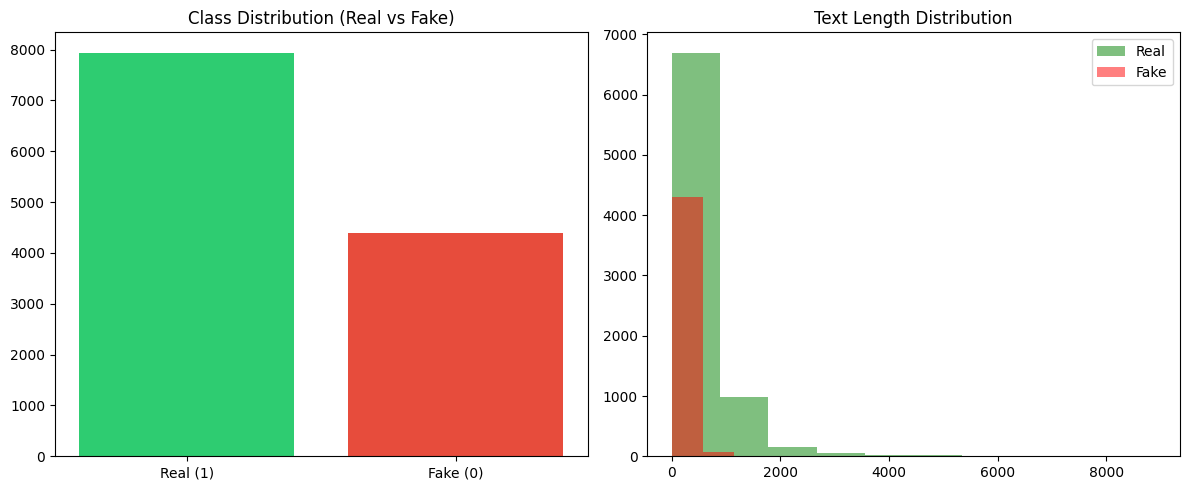

In [9]:
# Calculate character length for each text
combined['TextLength'] = combined['Text'].astype(str).apply(len)

# Visualization of class distribution and text lengths
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Plot label distribution
counts = combined['Label'].value_counts()
axes[0].bar(['Real (1)', 'Fake (0)'], [counts[1], counts[0]], color=['#2ecc71', '#e74c3c'])
axes[0].set_title('Class Distribution (Real vs Fake)')

# Plot text length histograms per class
axes[1].hist(combined[combined['Label']==1]['TextLength'], alpha=0.5, label='Real', color='green')
axes[1].hist(combined[combined['Label']==0]['TextLength'], alpha=0.5, label='Fake', color='red')
axes[1].set_title('Text Length Distribution')
axes[1].legend()

plt.tight_layout()
plt.show()

### **Chart**
**Chart 1** : Class Distribution
A bar chart showing how many real vs fake records you have in the combined dataset. 

**Chart 2** : Text Length by Class
A histogram showing if fake news tends to be shorter or longer than real news.

***
### **Text Preprocessing**

In [10]:
# Setup NLP tools
arabic_stopwords = set(stopwords.words('arabic'))
st = ISRIStemmer()

def clean_text(text):
    text = str(text)
    # Normalize Arabic letter variants
    text = re.sub(r'[إأآا]', 'ا', text)
    text = re.sub(r'ى', 'ي', text)
    text = re.sub(r'ة', 'ه', text)
    # Remove diacritics
    text = re.sub(r'[\u064B-\u065F\u0670]', '', text)
    # Remove URLs
    text = re.sub(r'http\S+|www\S+', '', text)
    # Remove punctuation and numbers
    text = re.sub(r'[^\w\s]', '', text)
    text = re.sub(r'\d+', '', text)
    # Remove emojis
    text = emoji.replace_emoji(text, replace='')
    # Collapse repeated characters (هههههه → هه)
    text = re.sub(r'(.)\1{2,}', r'\1\1', text)
    # Stopwords + stemming, skip single chars
    words = text.split()
    words = [st.stem(w) for w in words if w not in arabic_stopwords and len(w) > 1]
    return ' '.join(words).strip()

# Apply cleaning to the dataset
combined['clean_text'] = combined['Text'].apply(clean_text)
print(' Done')

 Done


***
### **Model Training**

In [11]:
X = combined['clean_text']
y = combined['Label']

# Split data into Train and Test sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
# Convert text to numerical features using TF-IDF
vectorizer = TfidfVectorizer(
    max_features=20000,
    ngram_range=(1, 3),
    sublinear_tf=True,
    min_df=1
)

X_train_vec = vectorizer.fit_transform(X_train)
X_test_vec  = vectorizer.transform(X_test)

print(f'Train: {len(X_train)} | Test: {len(X_test)}')
print(f'Feature matrix: {X_train_vec.shape}')

Train: 9861 | Test: 2466
Feature matrix: (9861, 20000)


In [12]:
# Train the Logistic Regression model
model = LogisticRegression(max_iter=1000, class_weight='balanced', C=100)
model.fit(X_train_vec, y_train)
print('Model trained')

Model trained


***
### **Model Evaluation**

Accuracy: 0.9294

Classification Report:
              precision    recall  f1-score   support

    Fake (0)       0.92      0.88      0.90       877
    Real (1)       0.94      0.96      0.95      1589

    accuracy                           0.93      2466
   macro avg       0.93      0.92      0.92      2466
weighted avg       0.93      0.93      0.93      2466



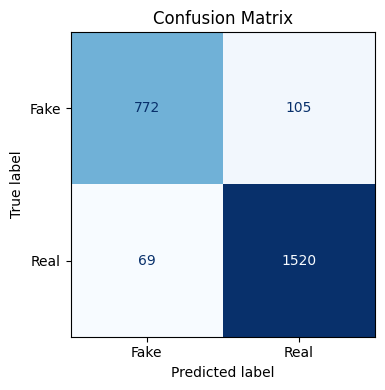

In [13]:
y_pred = model.predict(X_test_vec)

print(f'Accuracy: {accuracy_score(y_test, y_pred):.4f}')
print()
print('Classification Report:')
print(classification_report(y_test, y_pred, target_names=['Fake (0)', 'Real (1)']))

cm = confusion_matrix(y_test, y_pred)
fig, ax = plt.subplots(figsize=(5, 4))
ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Fake', 'Real']).plot(
    ax=ax, colorbar=False, cmap='Blues'
)
ax.set_title('Confusion Matrix')
plt.tight_layout()
plt.show()

In [14]:
pipe = Pipeline([
    ('tfidf', TfidfVectorizer(max_features=20000, ngram_range=(1,3), sublinear_tf=True, min_df=1)),
    ('clf',   LogisticRegression(max_iter=1000, class_weight='balanced', C=100))
])

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_acc = cross_val_score(pipe, X, y, cv=cv, scoring='accuracy')
cv_f1  = cross_val_score(pipe, X, y, cv=cv, scoring='f1_macro')

print('5-Fold Cross Validation:')
print(f'  Accuracy : {cv_acc.mean():.4f} ± {cv_acc.std():.4f}')
print(f'  F1-macro : {cv_f1.mean():.4f} ± {cv_f1.std():.4f}')

5-Fold Cross Validation:
  Accuracy : 0.9263 ± 0.0038
  F1-macro : 0.9192 ± 0.0042


***
### **Exporting the Model**

In [15]:
pickle.dump(vectorizer, open("models/vectorizer.pkl", "wb"))  
pickle.dump(model, open("models/model.pkl", "wb"))
print("Saved")

Saved
